In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from statsmodels.stats.mediation import Mediation
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
from pingouin import ancova
import matplotlib.cm as cm
from scipy.stats.stats import pearsonr
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

/tmp/ipykernel_2471627/4070851529.py:18: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr
/home/ubuntu/.local/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# 1 Load data from "2 BrainAge"

In [2]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Preprocessing and descriptives

## 2.1 Data

In [3]:
main_test.head()

,ID,Age,Gender,IS,TPA,VPA,MPA,MVPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,BADA2009,BADASEG,BADDesikan
10,1001365,71.0,Female,11025,3396.9600,20.1600,514.0800,554.4000,2862.7200,594.0,240.0,240.0,20.0,73.0,28.2030,70.0,106.0,-3.509850,-6.181273,1.240736
17,1001748,48.0,Female,11025,3126.8160,265.3056,596.9376,1127.5488,2264.5728,462.0,0.0,2400.0,34.0,52.0,25.7857,75.0,124.0,4.104798,-2.846061,-4.816671
20,1001984,69.0,Female,11026,2468.4192,9.9936,579.6288,599.6160,1878.7968,693.0,960.0,0.0,26.0,76.0,25.7422,79.0,120.0,1.474396,-4.325514,3.782237
21,1002138,56.0,Female,11025,2465.2224,29.1168,427.0464,485.2800,2009.0592,2970.0,720.0,240.0,18.0,56.0,33.5680,75.0,134.0,-4.857729,-11.966036,18.051254
23,1002288,63.0,Female,11025,2559.7728,109.1376,704.4336,922.7088,1746.2016,264.0,960.0,0.0,30.0,85.0,27.4762,84.0,146.0,-5.136301,-4.721379,14.815543


## 2.2 Remove outliers on SR PA

In [4]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 563
5422


## 2.3 Convert SRPA from MET min/week to min/week

In [5]:
main_test["SRLPA"] = main_test["SRLPA"]/3.3
main_test["SRMPA"] = main_test["SRMPA"]/4
main_test["SRVPA"] = main_test["SRVPA"]/8

main_train["SRLPA"] = main_train["SRLPA"]/3.3
main_train["SRMPA"] = main_train["SRMPA"]/4
main_train["SRVPA"] = main_train["SRVPA"]/8

## 2.4 Remove people with Gender other than Male or Female

In [6]:
before = main_test.shape[0]
main_test = main_test[(main_test["Gender"] == "Female") | (main_test["Gender"] == "Male")]
after = main_test.shape[0]
print("Gender not Male or Female:", before-after)
print(after)

Gender not Male or Female: 0
5422


## 2.5 Test set descriptives

In [7]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Gender"] == "Female"]
male = main_test[main_test["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("LPA")
mean = female["LPA"].mean()
print("Female", mean)
std = female["LPA"].std()
print("Female",std)
mean = male["LPA"].mean()
print("Male",mean)
std = male["LPA"].std()
print("Male",std)

print("MPA")
mean = female["MPA"].mean()
print("Female", mean)
std = female["MPA"].std()
print("Female",std)
mean = male["MPA"].mean()
print("Male",mean)
std = male["MPA"].std()
print("Male",std)

print("VPA")
mean = female["VPA"].mean()
print("Female", mean)
std = female["VPA"].std()
print("Female",std)
mean = male["VPA"].mean()
print("Male",mean)
std = male["VPA"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

print("IS")
print("Female")
print(female["IS"].value_counts())
print("Male")
print(male["IS"].value_counts())

Number of females: 2898
NUmber of males: 2524
Age
Female 63.49482401656315
Female 7.556813291182583
Male 65.49207606973059
Male 7.824543474679913
LPA
Female 2056.1930434782607
Female 406.8644273491336
Male 1885.7437103011096
Male 405.84204331256376
MPA
Female 498.95904596273294
Female 226.04598507597225
Male 467.3088513470682
Male 219.2158898210811
VPA
Female 31.376486956521767
Female 41.49015419937569
Male 36.690498256735374
Male 47.658656646516
SRLPA
Female 238.95893719806764
Female 217.25728613523955
Male 228.2757527733756
Male 214.98428822575775
SRMPA
Female 164.53864734299518
Female 192.7345503376467
Male 151.85340729001584
Male 189.56415554857819
SRVPA
Female 59.55106970324362
Female 78.7575967190967
Male 69.24366085578447
Male 86.54336440961143
DBP
Female 79.28433402346445
Female 10.25709733932206
Male 83.24167987321711
Male 10.189301689365152
SBP
Female 133.13077984817116
Female 19.121772759199146
Male 140.57369255150556
Male 17.608384631991797
BMI
Female 25.811531090407172
Fem

## 2.6 Train set descriptives

In [8]:
# get mean and std for all variables for males and females seperately for the train set
female = main_train[main_train["Gender"] == "Female"]
male = main_train[main_train["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

print("IS")
print("Female")
print(female["IS"].value_counts())
print("Male")
print(male["IS"].value_counts())

Number of females: 11117
NUmber of males: 10325
Age
Female 63.836196815687686
Female 7.503871583194821
Male 65.00474576271186
Male 7.7586035249436
SRLPA
Female 298.2378176218238
Female 313.1460826341599
Male 281.3274268104777
Male 305.1743806928862
SRMPA
Female 209.46342536574633
Female 278.4161491364909
Male 204.4325335681268
Male 282.84283897997835
SRVPA
Female 71.76625233747663
Female 115.02450032515416
Male 92.68567026194145
Male 143.56977799285923
BMI
Female 26.138465982351878
Female 4.582669799430477
Male 27.191944284882588
Male 3.7562568482626655
DBP
Female 79.32254626489681
Female 10.228206380591313
Male 83.40178664173678
Male 10.089943983473264
SBP
Female 132.82763298130027
Female 19.06073106946566
Male 140.33489145112705
Male 17.42547072290952
HG
Female 25.921382796281254
Female 6.415775125843123
Male 42.48262473306154
Male 8.766859109259675
HR
Female 69.22216839453542
Female 10.393253848960265
Male 66.84958969564765
Male 11.43598977944362
IS
Female
11025    6408
11027    305

## 2.7 Age and BrainAge

In [9]:
# # plot Age by Gender
# plt.figure()
# sns.kdeplot(data = main_test, x= 'Age', hue = 'Gender', fill=True, palette = "crest")
# plt.title("Age x Gender")
# plt.show()

# # plot BrainAGE by Gender
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'Gender', fill=True, palette = "crest")
# plt.title("BrainAge x Gender")
# plt.show()

# # plot BrainAGE by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'IS', fill=True, palette = "crest")
# plt.title("BrainAge x Imaging site")
# plt.show()

# # plot Age by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'Age', hue = 'IS', fill=True, palette = "crest")
# plt.title("Age x Imaging site")
# plt.show()

# # plot Moderate PA by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'MPA', hue = 'IS', fill=True, palette = "crest")
# plt.title("Moderate PA x Imaging site")
# plt.show()

# # plot BrainAGE Segmentations
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', fill=True, label="Destrieux")
# sns.kdeplot(data = main_test, x= 'BADASEG', fill=True, label="ASEG")
# sns.kdeplot(data = main_test, x= 'BADDesikan', fill=True, label="Desikan")
# plt.xlabel("BrainAGE", fontsize=14)
# plt.ylabel("Density", fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.legend(fontsize=14)
# plt.show()

## 2.8 Physical activity

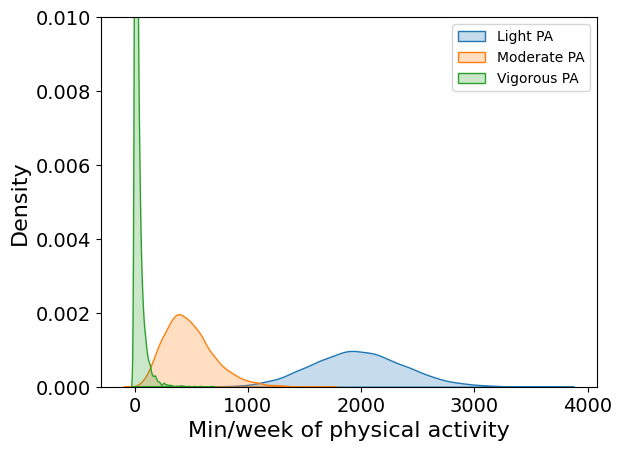

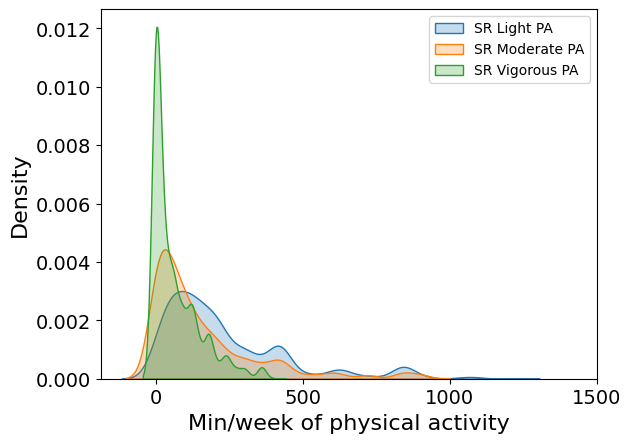

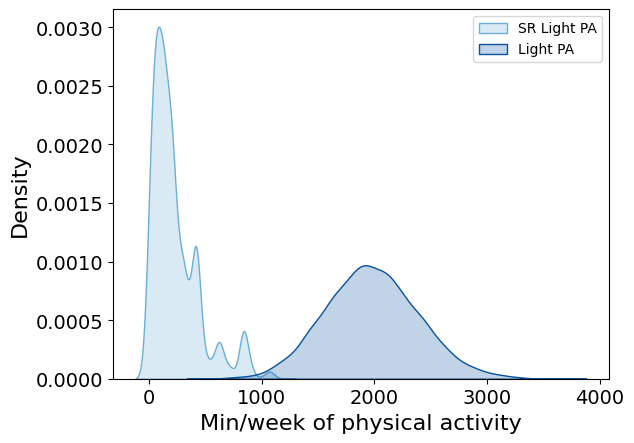

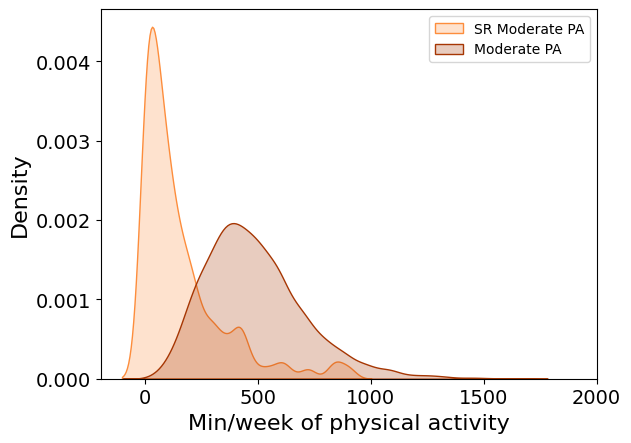

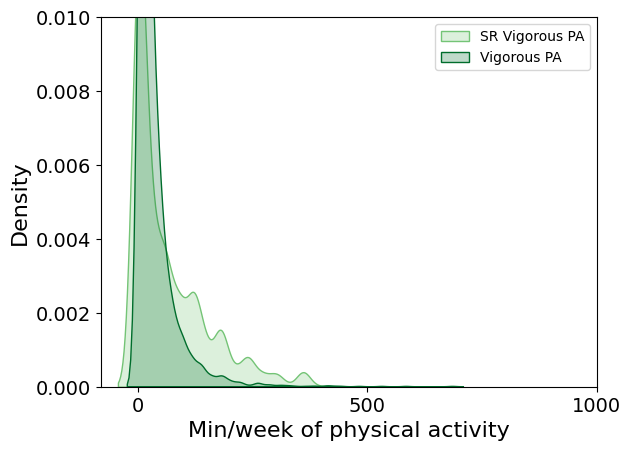

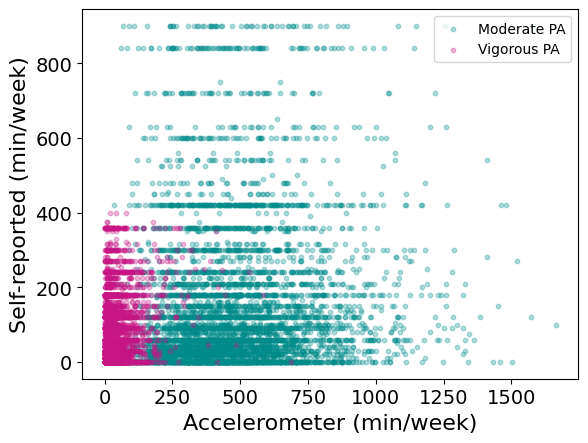

In [10]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately

plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,5000,1000),fontsize = 14)
plt.ylim(0,0.01)
plt.ylabel("Density",fontsize = 16)
plt.yticks(fontsize = 14)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2000,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,4500,1000),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2500,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
plt.ylim(0,0.01)
plt.xticks(range(0,1500,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.legend()
plt.show()

plt.figure()
plt.scatter("MPA", "SRMPA", data = main_test, label = "Moderate PA", alpha=0.3, s=10, color = "darkcyan")
plt.scatter("VPA", "SRVPA", data = main_test, label = "Vigorous PA", alpha=0.3, s=10, color = "mediumvioletred")
plt.ylabel("Self-reported (min/week)", fontsize = 16)
plt.xlabel("Accelerometer (min/week)", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc="best")
plt.show()

## 2.9 Fitness

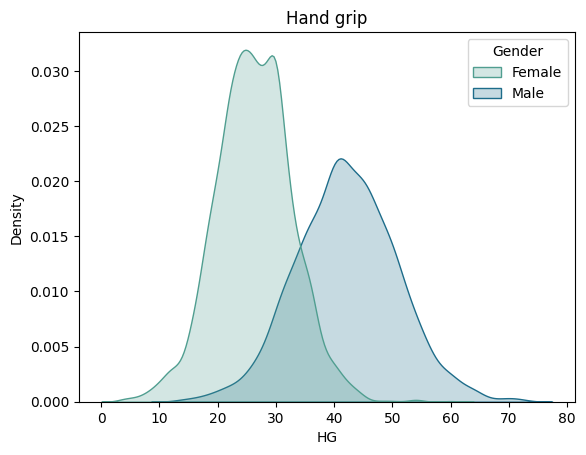

In [11]:
# plot dominant hand grip strength
plt.figure()
sns.kdeplot(data = main_test, x= 'HG', hue = 'Gender', fill=True, palette = "crest")
plt.title("Hand grip")
plt.show()

## 2.10 Health

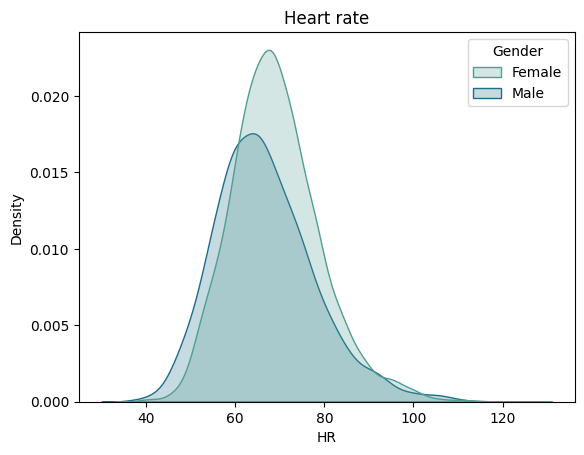

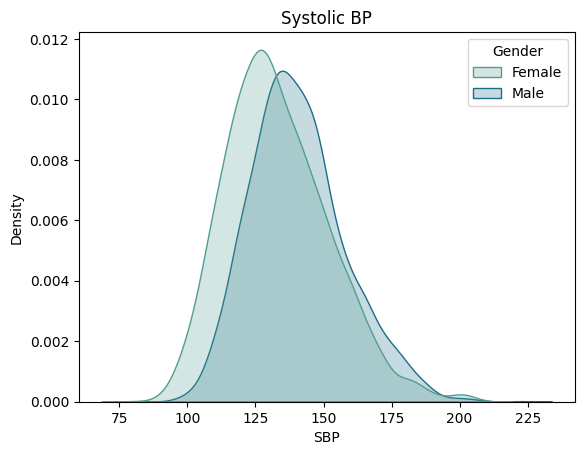

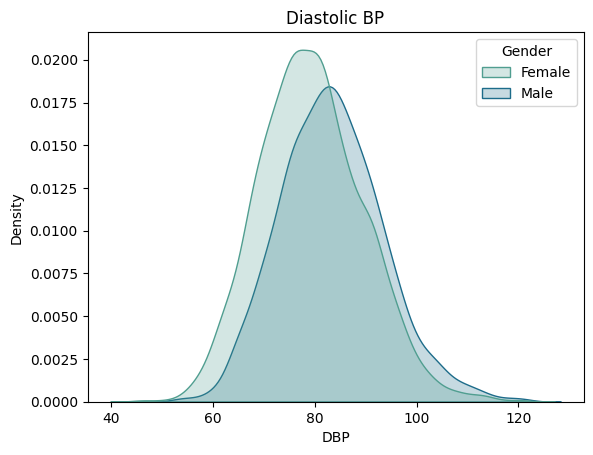

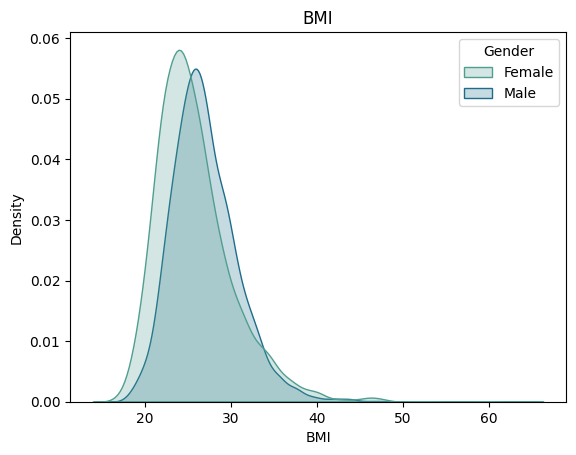

In [12]:
# plot Heart rate
plt.figure()
sns.kdeplot(data = main_test, x= 'HR', hue = 'Gender', fill=True, palette = "crest")
plt.title("Heart rate")
plt.show()

# plot systolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'SBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Systolic BP")
plt.show()

# plot diastolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'DBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Diastolic BP")
plt.show()

# plot BMI
plt.figure()
sns.kdeplot(data = main_test, x= 'BMI', hue = 'Gender', fill=True, palette = "crest")
plt.title("BMI")
plt.show()

# 3 Recode and compute variables

## 3.1 Recode variables

In [13]:
# recode Imaging site and Gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 0, '11026': 1,'11027': 2, '11028': 3})
main_test["Gender"] = main_test["Gender"].map({"Female":0, "Male":1})
main_test["Gender"] = main_test["Gender"].astype("int")
main_test = main_test.rename(columns={"BADA2009": "BA"})


## 3.2 Compute Combined Risk score

In [14]:
# standardized = main_test[:]
# standardized[["MPA","SRMPA","HR", "DBP","HG","BMI"]] = stats.zscore(main_test[["MPA","SRMPA","HR", "DBP","HG","BMI"]], nan_policy='omit')

In [15]:
# combined risk score for self-report and accelerometer -> summing z-scores of best PA and health and fitness variables
# multiply fitness and PA by -1
# main_test["CR"] = standardized["MPA"]*-1 + standardized["HG"]*-1 + standardized["DBP"] + standardized["HR"] + standardized["BMI"]
# main_test["SRCR"] = standardized["SRMPA"]*-1 + standardized["HG"]*-1 + standardized["DBP"] + standardized["HR"] + standardized["BMI"]

## 3.3 Remove effect of Age on all predictor variables (regression -> residuals)

In [16]:
model = ols("LPA ~ Age", data = main_test).fit()
main_test["LPA"] = model.resid

model = ols("MPA ~ Age", data = main_test).fit()
main_test["MPA"] = model.resid

model = ols("VPA ~ Age", data = main_test).fit()
main_test["VPA"] = model.resid

model = ols("SRLPA ~ Age", data = main_test).fit()
main_test["SRLPA"] = model.resid

model = ols("SRMPA ~ Age", data = main_test).fit()
main_test["SRMPA"] = model.resid

model = ols("SRVPA ~ Age", data = main_test).fit()
main_test["SRVPA"] = model.resid

# model = ols("CR ~ Age", data = main_test).fit()
# main_test["CR"] = model.resid

# model = ols("SRCR ~ Age", data = main_test).fit()
# main_test["SRCR"] = model.resid

model = ols("HR ~ Age", data = main_test).fit()
main_test["HR"] = model.resid

model = ols("DBP ~ Age", data = main_test).fit()
main_test["DBP"] = model.resid

model = ols("SBP ~ Age", data = main_test).fit()
main_test["SBP"] = model.resid

model = ols("BMI ~ Age", data = main_test).fit()
main_test["BMI"] = model.resid

model = ols("HG ~ Age", data = main_test).fit()
main_test["HG"] = model.resid

## 3.4 Descriptives for combined risk score (only test)

In [17]:
# female = main_test[main_test["Gender"] == 0]
# male = main_test[main_test["Gender"]== 1]

# print("CR")
# mean = female["CR"].mean()
# print("Female", mean)
# std = female["CR"].std()
# print("Female",std)
# mean = male["CR"].mean()
# print("Male",mean)
# std = male["CR"].std()
# print("Male",std)

# print("SRCR")
# mean = female["SRCR"].mean()
# print("Female", mean)
# std = female["SRCR"].std()
# print("Female",std)
# mean = male["SRCR"].mean()
# print("Male",mean)
# std = male["SRCR"].std()
# print("Male",std)

# 4 Reorder dataframe and delete unused variables

In [18]:
main_test = main_test[['Age', 'Gender', 'IS' , 'LPA', 'MPA', 'VPA', 'SRLPA', 'SRMPA', 'SRVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', 'BA']]

# 5 Correlation heatmap

In [19]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

,Age,Gender,IS,LPA,MPA,VPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,BA
Age,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.7209
Gender,0.0,0.0,0.3298,0.0,0.0011,0.0,0.0178,0.0002,0.0,0.0,0.0,0.0,0.0,0.0,0.002
IS,0.0,0.3298,0.0,0.0368,0.0017,0.0113,0.0003,0.7057,0.1238,0.4379,0.0102,0.2108,0.4153,0.0366,0.1875
LPA,1.0,0.0,0.0368,0.0,0.0,0.0,0.0,0.0,0.0003,0.0,0.2256,0.0,0.0,0.001,0.384
MPA,1.0,0.0011,0.0017,0.0,0.0,0.0,0.0,0.0,0.0,0.0077,0.0,0.0,0.0,0.0008,0.0005
VPA,1.0,0.0,0.0113,0.0,0.0,0.0,0.1196,0.0039,0.0,0.0,0.0,0.0,0.0,0.0499,0.2401
SRLPA,1.0,0.0178,0.0003,0.0,0.0,0.1196,0.0,0.0,0.0,0.1762,0.002,0.0,0.3317,0.6353,0.7212
SRMPA,1.0,0.0002,0.7057,0.0,0.0,0.0039,0.0,0.0,0.0,0.4189,0.0,0.0,0.0022,0.293,0.738
SRVPA,1.0,0.0,0.1238,0.0003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0633,0.2198,0.6768
HG,1.0,0.0,0.4379,0.0,0.0077,0.0,0.1762,0.4189,0.0,0.0,0.0,0.0,0.0,0.0,0.7434


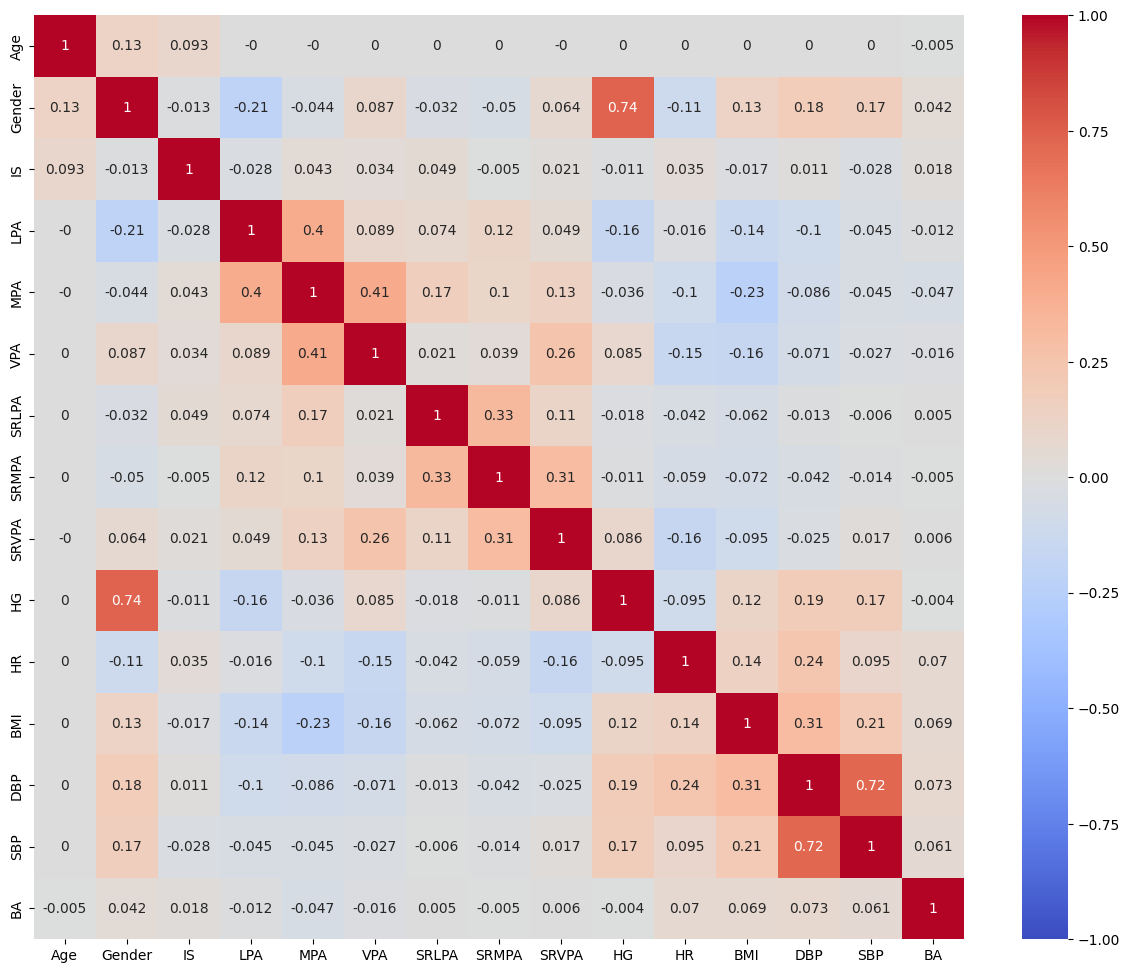

In [20]:
corr = main_test.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)
calculate_pvalues(main_test)

# 6 Models OLS

## 6.1 Single Predictor Models

### 6.1.1 Accelerometer PA

In [21]:
mpa = ols('BA ~ MPA + Age + Gender + IS + Gender:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.983
Date:                Sat, 27 May 2023   Prob (F-statistic):           0.000148
Time:                        11:09:35   Log-Likelihood:                -18312.
No. Observations:                5422   AIC:                         3.664e+04
Df Residuals:                    5416   BIC:                         3.668e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0832      0.807      0.103      0.9

### 6.1.2 Self-report PA

In [22]:
srmpa = ols('BA ~ SRMPA + Age + Gender + IS + Gender:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.420
Date:                Sat, 27 May 2023   Prob (F-statistic):            0.00435
Time:                        11:09:35   Log-Likelihood:                -18316.
No. Observations:                5422   AIC:                         3.664e+04
Df Residuals:                    5416   BIC:                         3.668e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0477      0.808      0.059   

### 6.1.3 Combined risk scores (Acc)

In [23]:
# cr = ols('BA ~ CR + Age + Gender + IS + Gender:CR', missing='drop', data = main_test).fit()
# print(cr.summary())

# #calculate effect size
# results = cr
# coefficients = results.params
# stderr = results.bse
# effect_size = coefficients / (stderr* np.sqrt(5422))
# print(effect_size)

#### 6.1.3.1 Males

In [24]:
# male = main_test[main_test["Gender"] == 1]

# crm = ols('BA ~ CR + Age + IS', missing='drop', data = male).fit()
# print(crm.summary())

# #calculate effect size
# results = crm
# coefficients = results.params
# stderr = results.bse
# effect_size = coefficients / (stderr* np.sqrt(5422))
# print(effect_size)

#### 6.1.3.2 Females

In [25]:
# female = main_test[main_test["Gender"] == 0]

# crf = ols('BA ~ CR + Age + IS', missing='drop', data = female).fit()
# print(crf.summary())

# #calculate effect size
# results = crf
# coefficients = results.params
# stderr = results.bse
# effect_size = coefficients / (stderr* np.sqrt(5422))
# print(effect_size)

### 6.1.4 Combined risk score (SR)

In [26]:
# srcr = ols('BA ~ SRCR + Age + Gender + IS + Gender:SRCR', missing='drop', data = main_test).fit()
# print(srcr.summary())

# #calculate effect size
# results = srcr
# coefficients = results.params
# stderr = results.bse
# effect_size = coefficients / (stderr* np.sqrt(5422))
# print(effect_size)

## 6.2 Multiple Predictor & Comparison Models

### 6.2.1 Covariates

In [27]:
cov_model = ols('BA ~ Gender + Age + IS', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.057
Date:                Sat, 27 May 2023   Prob (F-statistic):            0.00686
Time:                        11:09:36   Log-Likelihood:                -18319.
No. Observations:                5422   AIC:                         3.665e+04
Df Residuals:                    5418   BIC:                         3.667e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0708      0.808      0.088      0.9

### 6.2.2 PAF / MPA

In [28]:
no_mpa = ols('BA ~ HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_mpa.summary())

#calculate effect size
results = no_mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     8.983
Date:                Sat, 27 May 2023   Prob (F-statistic):           7.87e-15
Time:                        11:09:36   Log-Likelihood:                -18280.
No. Observations:                5422   AIC:                         3.658e+04
Df Residuals:                    5411   BIC:                         3.666e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8897      0.218     -4.087      0.0

### 6.2.3 PAF / HG

In [29]:
no_hg = ols('BA ~ MPA + DBP + HR + BMI + Gender + IS + MPA:Gender + DBP:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_hg.summary())

#calculate effect size
results = no_hg
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     7.460
Date:                Sat, 27 May 2023   Prob (F-statistic):           6.98e-12
Time:                        11:09:37   Log-Likelihood:                -18288.
No. Observations:                5422   AIC:                         3.660e+04
Df Residuals:                    5411   BIC:                         3.667e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6022      0.153     -3.940      0.0

### 6.2.4 PAF / HR

In [30]:
no_hr = ols('BA ~ HG + DBP + MPA + BMI + Gender + IS + HG:Gender + DBP:Gender + MPA:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_hr.summary())

#calculate effect size
results = no_hr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     8.035
Date:                Sat, 27 May 2023   Prob (F-statistic):           5.45e-13
Time:                        11:09:37   Log-Likelihood:                -18285.
No. Observations:                5422   AIC:                         3.659e+04
Df Residuals:                    5411   BIC:                         3.666e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8634      0.217     -3.972      0.0

### 6.2.5 PAF / DBP

In [31]:
no_dbp = ols('BA ~ HG + MPA + HR + BMI + Gender + IS + HG:Gender + MPA:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_dbp.summary())

#calculate effect size
results = no_dbp
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     8.387
Date:                Sat, 27 May 2023   Prob (F-statistic):           1.14e-13
Time:                        11:09:37   Log-Likelihood:                -18283.
No. Observations:                5422   AIC:                         3.659e+04
Df Residuals:                    5411   BIC:                         3.666e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9135      0.218     -4.200      0.0

### 6.2.6 PAF / BMI

In [32]:
no_bmi = ols('BA ~ HG + DBP + HR + MPA + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + MPA:Gender', missing='drop', data = main_test).fit()
print(no_bmi.summary())

#calculate effect size
results = no_bmi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     8.461
Date:                Sat, 27 May 2023   Prob (F-statistic):           8.16e-14
Time:                        11:09:37   Log-Likelihood:                -18283.
No. Observations:                5422   AIC:                         3.659e+04
Df Residuals:                    5411   BIC:                         3.666e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8989      0.218     -4.129      0.0

### 6.2.7 PAF

In [33]:
cr2 = ols('BA ~ MPA +HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender + MPA:Gender', missing='drop', data = main_test).fit()
print(cr2.summary())

#calculate effect size
results = cr2
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     7.888
Date:                Sat, 27 May 2023   Prob (F-statistic):           8.56e-15
Time:                        11:09:37   Log-Likelihood:                -18278.
No. Observations:                5422   AIC:                         3.658e+04
Df Residuals:                    5409   BIC:                         3.667e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8871      0.218     -4.073      0.0

### 6.2.8 SR PAF

In [34]:
srcr2 = ols('BA ~ SRMPA + HG + DBP + HR + BMI + Gender + IS + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender + SRMPA:Gender', missing='drop', data = main_test).fit()
print(srcr2.summary())

#calculate effect size
results = srcr2
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     7.787
Date:                Sat, 27 May 2023   Prob (F-statistic):           1.46e-14
Time:                        11:09:38   Log-Likelihood:                -18278.
No. Observations:                5422   AIC:                         3.658e+04
Df Residuals:                    5409   BIC:                         3.667e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.9095      0.218     -4.172   

# 7 Model comparisons

## 7.1 Cov vs. PA

In [35]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  273088.362093      0.0         NaN       NaN       NaN
1    5416.0  272448.451431      2.0  639.910661  6.360389  0.001742


## 7.2 Cov vs. SRPA

In [36]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5418.0  273088.362093      0.0         NaN       NaN       NaN
1    5416.0  272840.277794      2.0  248.084298  2.462291  0.085335


## 7.3 PAF / MPA

In [37]:
model_comparison = anova_lm(no_mpa, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  269232.161999      0.0         NaN       NaN       NaN
1    5409.0  268994.522682      2.0  237.639316  2.389251  0.091795


## 7.4 SR PAF / SRMPA

In [38]:
model_comparison = anova_lm(no_mpa, srcr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  269232.161999      0.0         NaN       NaN       NaN
1    5409.0  269053.963093      2.0  178.198906  1.791235  0.166853


## 7.5 PAF / HG

In [39]:
model_comparison = anova_lm(no_hg, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  269979.720067      0.0         NaN       NaN       NaN
1    5409.0  268994.522682      2.0  985.197385  9.905281  0.000051


## 7.6 PAF / DBP

In [40]:
model_comparison = anova_lm(no_dbp, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  269524.382380      0.0         NaN       NaN       NaN
1    5409.0  268994.522682      2.0  529.859698  5.327267  0.004883


## 7.7 PAF / HR

In [41]:
model_comparison = anova_lm(no_hr, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5411.0  269696.826578      0.0         NaN       NaN       NaN
1    5409.0  268994.522682      2.0  702.303895  7.061039  0.000866


## 7.8 PAF / BMI

In [42]:
model_comparison = anova_lm(no_bmi, cr2)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff        F    Pr(>F)
0    5411.0  269487.993633      0.0         NaN      NaN       NaN
1    5409.0  268994.522682      2.0  493.470951  4.96141  0.007035


# 8 Standardization of all variables

In [43]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Gender","IS"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Gender","IS"]], nan_policy='omit')

# 9 Mediation analysis

## 9.1 BMI

In [44]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.066347       -0.106459       -0.034244    0.000
ACME (treated)           -0.066347       -0.106459       -0.034244    0.000
ADE (control)            -0.013656       -0.221762        0.187893    0.908
ADE (treated)            -0.013656       -0.221762        0.187893    0.908
Total effect             -0.080003       -0.284400        0.133746    0.432
Prop. mediated (control)  0.474445       -7.774903        6.952385    0.432
Prop. mediated (treated)  0.474445       -7.774903        6.952385    0.432
ACME (average)           -0.066347       -0.106459       -0.034244    0.000
ADE (average)            -0.013656       -0.221762        0.187893    0.908
Prop. mediated (average)  0.474445       -7.774903        6.952385    0.432


In [45]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.102482       -0.154250       -0.058017    0.000
ACME (treated)           -0.102482       -0.154250       -0.058017    0.000
ADE (control)            -0.232742       -0.432226       -0.032549    0.024
ADE (treated)            -0.232742       -0.432226       -0.032549    0.024
Total effect             -0.335224       -0.537025       -0.143905    0.002
Prop. mediated (control)  0.303580        0.145979        0.753535    0.002
Prop. mediated (treated)  0.303580        0.145979        0.753535    0.002
ACME (average)           -0.102482       -0.154250       -0.058017    0.000
ADE (average)            -0.232742       -0.432226       -0.032549    0.024
Prop. mediated (average)  0.303580        0.145979        0.753535    0.002


In [46]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA ", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.077824       -0.118443       -0.042246    0.000
ACME (treated)           -0.077824       -0.118443       -0.042246    0.000
ADE (control)            -0.038637       -0.229910        0.157818    0.700
ADE (treated)            -0.038637       -0.229910        0.157818    0.700
Total effect             -0.116461       -0.314673        0.076288    0.242
Prop. mediated (control)  0.513695       -8.088922        8.478171    0.242
Prop. mediated (treated)  0.513695       -8.088922        8.478171    0.242
ACME (average)           -0.077824       -0.118443       -0.042246    0.000
ADE (average)            -0.038637       -0.229910        0.157818    0.700
Prop. mediated (average)  0.513695       -8.088922        8.478171    0.242


## 9.2 DBP

In [47]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.051813       -0.087162       -0.024907    0.000
ACME (treated)           -0.051813       -0.087162       -0.024907    0.000
ADE (control)            -0.030199       -0.215668        0.144716    0.728
ADE (treated)            -0.030199       -0.215668        0.144716    0.728
Total effect             -0.082012       -0.268449        0.094152    0.400
Prop. mediated (control)  0.387874       -8.674733        7.656794    0.400
Prop. mediated (treated)  0.387874       -8.674733        7.656794    0.400
ACME (average)           -0.051813       -0.087162       -0.024907    0.000
ADE (average)            -0.030199       -0.215668        0.144716    0.728
Prop. mediated (average)  0.387874       -8.674733        7.656794    0.400


In [48]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.041879       -0.074048       -0.016275    0.000
ACME (treated)           -0.041879       -0.074048       -0.016275    0.000
ADE (control)            -0.291227       -0.466062       -0.111220    0.006
ADE (treated)            -0.291227       -0.466062       -0.111220    0.006
Total effect             -0.333106       -0.514757       -0.150041    0.004
Prop. mediated (control)  0.123106        0.047771        0.320583    0.004
Prop. mediated (treated)  0.123106        0.047771        0.320583    0.004
ACME (average)           -0.041879       -0.074048       -0.016275    0.000
ADE (average)            -0.291227       -0.466062       -0.111220    0.006
Prop. mediated (average)  0.123106        0.047771        0.320583    0.004


In [49]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.036259       -0.066709       -0.012257    0.002
ACME (treated)           -0.036259       -0.066709       -0.012257    0.002
ADE (control)            -0.082254       -0.266121        0.107261    0.378
ADE (treated)            -0.082254       -0.266121        0.107261    0.378
Total effect             -0.118513       -0.304930        0.075093    0.196
Prop. mediated (control)  0.249207       -1.871359        3.008148    0.198
Prop. mediated (treated)  0.249207       -1.871359        3.008148    0.198
ACME (average)           -0.036259       -0.066709       -0.012257    0.002
ADE (average)            -0.082254       -0.266121        0.107261    0.378
Prop. mediated (average)  0.249207       -1.871359        3.008148    0.198


## 9.3 Heart rate

In [50]:
outcome_model = sm.OLS.from_formula("BA ~ HR + LPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.007915       -0.032285        0.015123    0.486
ACME (treated)           -0.007915       -0.032285        0.015123    0.486
ADE (control)            -0.074898       -0.251164        0.107714    0.428
ADE (treated)            -0.074898       -0.251164        0.107714    0.428
Total effect             -0.082813       -0.262287        0.103241    0.368
Prop. mediated (control)  0.054880       -1.381901        2.169005    0.638
Prop. mediated (treated)  0.054880       -1.381901        2.169005    0.638
ACME (average)           -0.007915       -0.032285        0.015123    0.486
ADE (average)            -0.074898       -0.251164        0.107714    0.428
Prop. mediated (average)  0.054880       -1.381901        2.169005    0.638


In [51]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.046517       -0.075882       -0.020470      0.0
ACME (treated)           -0.046517       -0.075882       -0.020470      0.0
ADE (control)            -0.286029       -0.477173       -0.098862      0.0
ADE (treated)            -0.286029       -0.477173       -0.098862      0.0
Total effect             -0.332546       -0.528861       -0.141388      0.0
Prop. mediated (control)  0.139148        0.055649        0.356091      0.0
Prop. mediated (treated)  0.139148        0.055649        0.356091      0.0
ACME (average)           -0.046517       -0.075882       -0.020470      0.0
ADE (average)            -0.286029       -0.477173       -0.098862      0.0
Prop. mediated (average)  0.139148        0.055649        0.356091      0.0


In [52]:
outcome_model = sm.OLS.from_formula("BA ~ HR + VPA", main_test)
mediator_model = sm.OLS.from_formula("HR ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.073853       -0.110831       -0.040133    0.000
ACME (treated)           -0.073853       -0.110831       -0.040133    0.000
ADE (control)            -0.041641       -0.228494        0.150615    0.698
ADE (treated)            -0.041641       -0.228494        0.150615    0.698
Total effect             -0.115494       -0.305405        0.075912    0.260
Prop. mediated (control)  0.488841       -8.824939        5.830749    0.260
Prop. mediated (treated)  0.488841       -8.824939        5.830749    0.260
ACME (average)           -0.073853       -0.110831       -0.040133    0.000
ADE (average)            -0.041641       -0.228494        0.150615    0.698
Prop. mediated (average)  0.488841       -8.824939        5.830749    0.260


## 9.4 Hand grip

In [53]:
outcome_model = sm.OLS.from_formula("BA ~ HG + LPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ LPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.007081       -0.024963        0.040900    0.676
ACME (treated)            0.007081       -0.024963        0.040900    0.676
ADE (control)            -0.086199       -0.275447        0.096214    0.394
ADE (treated)            -0.086199       -0.275447        0.096214    0.394
Total effect             -0.079118       -0.272773        0.103668    0.450
Prop. mediated (control) -0.037046       -1.817817        2.074822    0.806
Prop. mediated (treated) -0.037046       -1.817817        2.074822    0.806
ACME (average)            0.007081       -0.024963        0.040900    0.676
ADE (average)            -0.086199       -0.275447        0.096214    0.394
Prop. mediated (average) -0.037046       -1.817817        2.074822    0.806


In [54]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.001794       -0.005821        0.012955    0.676
ACME (treated)            0.001794       -0.005821        0.012955    0.676
ADE (control)            -0.338330       -0.518644       -0.148623    0.000
ADE (treated)            -0.338330       -0.518644       -0.148623    0.000
Total effect             -0.336536       -0.520007       -0.146147    0.000
Prop. mediated (control) -0.002994       -0.046244        0.020011    0.676
Prop. mediated (treated) -0.002994       -0.046244        0.020011    0.676
ACME (average)            0.001794       -0.005821        0.012955    0.676
ADE (average)            -0.338330       -0.518644       -0.148623    0.000
Prop. mediated (average) -0.002994       -0.046244        0.020011    0.676


In [55]:
outcome_model = sm.OLS.from_formula("BA ~ HG + VPA", main_test)
mediator_model = sm.OLS.from_formula("HG ~ VPA", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
print(res.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.002146       -0.018411        0.015272    0.744
ACME (treated)           -0.002146       -0.018411        0.015272    0.744
ADE (control)            -0.110601       -0.282210        0.078552    0.224
ADE (treated)            -0.110601       -0.282210        0.078552    0.224
Total effect             -0.112747       -0.283675        0.076117    0.218
Prop. mediated (control)  0.013664       -0.684981        0.446698    0.806
Prop. mediated (treated)  0.013664       -0.684981        0.446698    0.806
ACME (average)           -0.002146       -0.018411        0.015272    0.744
ADE (average)            -0.110601       -0.282210        0.078552    0.224
Prop. mediated (average)  0.013664       -0.684981        0.446698    0.806


# 10 LASSO Regression

## 10.1 Accelerometer PA

<Figure size 1200x900 with 0 Axes>

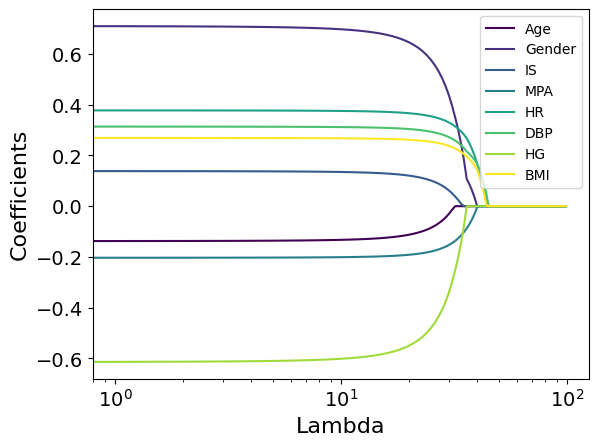

Optimal alpha: 0.0030538555088334154
[-0.13434772  0.70204226  0.13609324 -0.20188534  0.37645877  0.31272815
 -0.60603467  0.26829645]


In [56]:
df = main_test[["Age","Gender","IS", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age","Gender","IS", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age","Gender","IS", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

# lasso with cross validated alpha

lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_

# Print the coefficients
print(coefficients)

## 10.2 Self-report PA

<Figure size 1200x900 with 0 Axes>

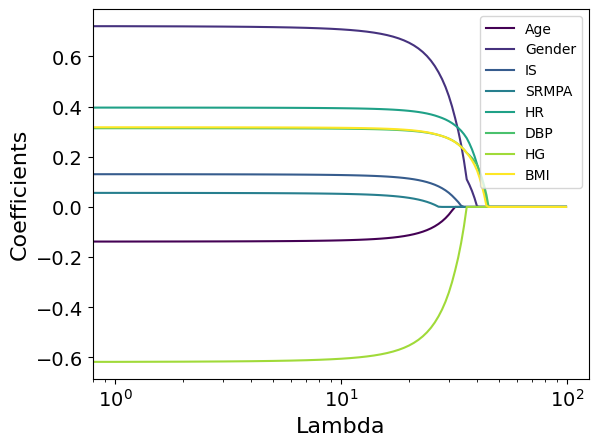

Optimal alpha: 0.0023101297000831605
[-0.13610815  0.71509742  0.12896431  0.05437828  0.39480416  0.31281527
 -0.61244251  0.31649796]


In [57]:
df = main_test[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "SRMPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_

# Print the coefficients
print(coefficients)

# 11 Quantification of combined risk

In [58]:
# plt.figure()
# plt.scatter("CR", "BA", data = female, label = "Female", alpha=0.5, s=10, color = "darkcyan")
# plt.scatter("CR", "BA", data = male, label = "Male", alpha=0.5, s=10, color = "mediumvioletred")
# plt.ylabel("BrainAGE", fontsize = 16)
# plt.xlabel("Combined risk score", fontsize = 16)
# plt.xticks(fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.legend(loc="best")
# plt.axline((0,0), slope=0.214, color="teal")
# plt.axline((0,0), slope=0.44, color="purple")
# plt.show()

# 12 Smaller Correlation Heatmap

,Age,Gender,MPA,SRMPA,HG,HR,BMI,DBP,BA
Age,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.7209
Gender,0.0,0.0,0.0011,0.0002,0.0,0.0,0.0,0.0,0.002
MPA,1.0,0.0011,0.0,0.0,0.0077,0.0,0.0,0.0,0.0005
SRMPA,1.0,0.0002,0.0,0.0,0.4189,0.0,0.0,0.0022,0.738
HG,1.0,0.0,0.0077,0.4189,0.0,0.0,0.0,0.0,0.7434
HR,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BMI,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DBP,1.0,0.0,0.0,0.0022,0.0,0.0,0.0,0.0,0.0
BA,0.7209,0.002,0.0005,0.738,0.7434,0.0,0.0,0.0,0.0


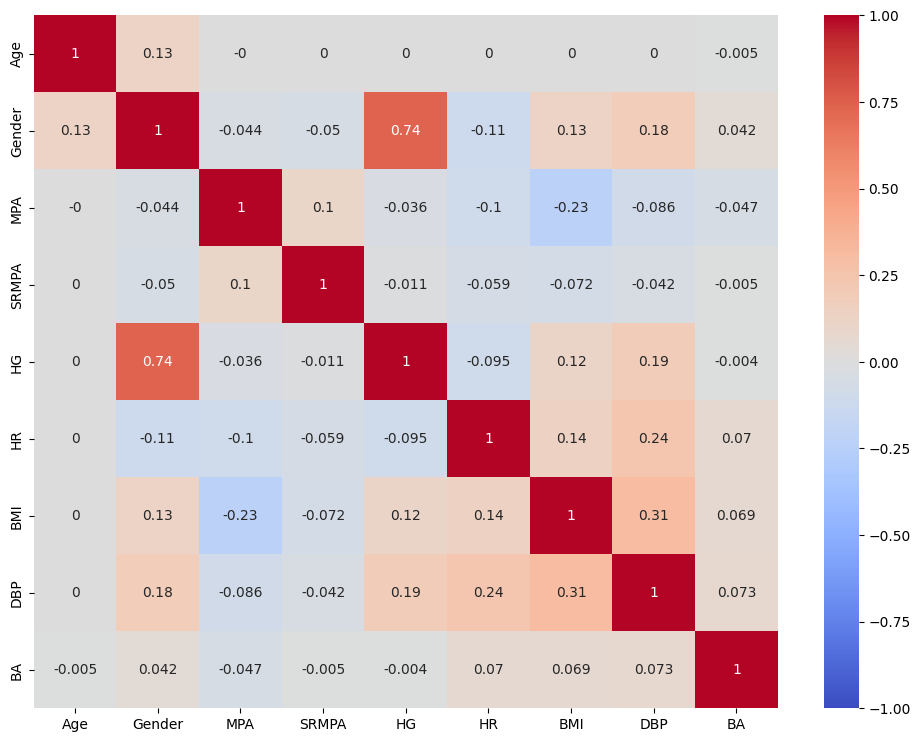

In [59]:
x = main_test
del x["IS"]
del x["LPA"]
del x["VPA"]
del x["SRLPA"]
del x["SRVPA"]
del x["SBP"]


corr = x.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(12,9)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)
calculate_pvalues(x)

# 13 Exploration vs. Validation

## 13.1 Import processed Validation set

In [60]:
validate = pd.read_pickle("3_validate.pkl")
validate = pd.DataFrame(validate)

## 13.2 BrainAGE distribution

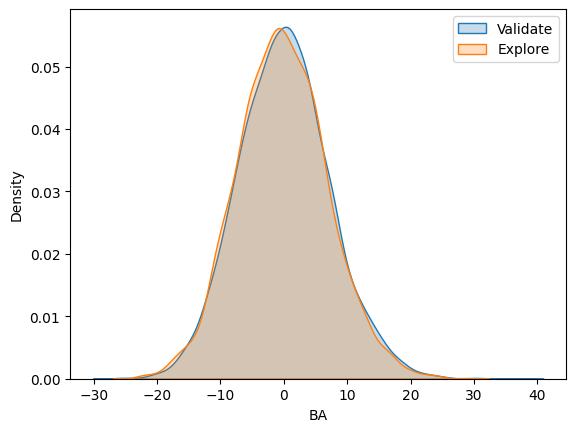

In [61]:
plt.figure()
sns.kdeplot(data = validate, x= 'BA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'BA', fill=True, label = "Explore")
plt.legend(loc="best")
plt.show()

## 13.3 MPA distribution

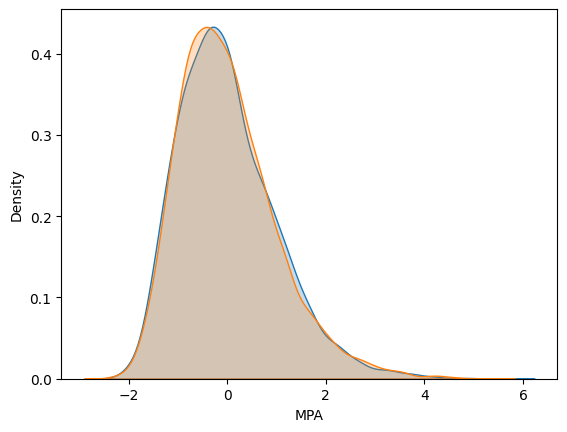

In [62]:
plt.figure()
sns.kdeplot(data = validate, x= 'MPA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Explore")
plt.show()